# Bargain-Bin 🛒
### "Buy cheap stocks" — sound advice that lost to growth for a generation

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A dependable premium?: Not supported](https://img.shields.io/badge/A_dependable_premium%3F-Not_supported-8b949e?style=flat-square)

Value investing — buy the cheap, shun the expensive — is gospel, the HML factor in every textbook. But for anyone who actually bought a value ETF in 2000, value *trailed* growth, and then spent thirteen years (2007–2020) going the wrong way. A real premium, yes — but a regime-switching bet, not the dependable edge it's sold as.

> 📓 **Plain-language layer.** The t-stats and the regimes are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (bargain_bin/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from quantlab.repro import as_of
from bargain_bin import data, strategy as st
ret = as_of(data.fetch_pairs())                # cache-first, pinned to the as-of (drops any in-progress month)
hml = st.hml(ret, "IVE", "IVW")                # S&P 500 value minus growth


## The answer first 🎯

| The belief | The tape (2000–2026) |
|---|---|
| "Cheap beats expensive" | Value − growth = **−1.3%/yr**; value's Sharpe < growth's. |
| "A dependable premium" | Strong pre-2007, then a **−5%/yr lost decade** 2007–2020. |
| "Just hold value" | You'd have abandoned it during the thirteen years it bled. |

## 1 · The claim

Value (Fama-French HML; Lakonishok-Shleifer-Vishny 1994): cheap stocks — high book-to-market — out-earn glamour stocks, a premium for patience (or for risk). The rationale for every value fund and factor tilt.

## 2 · So what?

Value is one of the two or three factors people actually allocate to. If the premium has been negative for a generation of investors, a core piece of portfolio orthodoxy needs re-examining — and the 'just be patient' advice has real teeth.

## 3 · How would we even know?

Test it the way an investor accesses it — **value vs growth ETFs** — measure the spread and its t-stat, compare each side's Sharpe, and split the era into pre-2007, the 2007–2020 lost decade, and 2021-on. (Those dates are the ones the value debate argues about — chosen with hindsight, not found by a test. We use them to *describe* the regimes, not to prove them.)

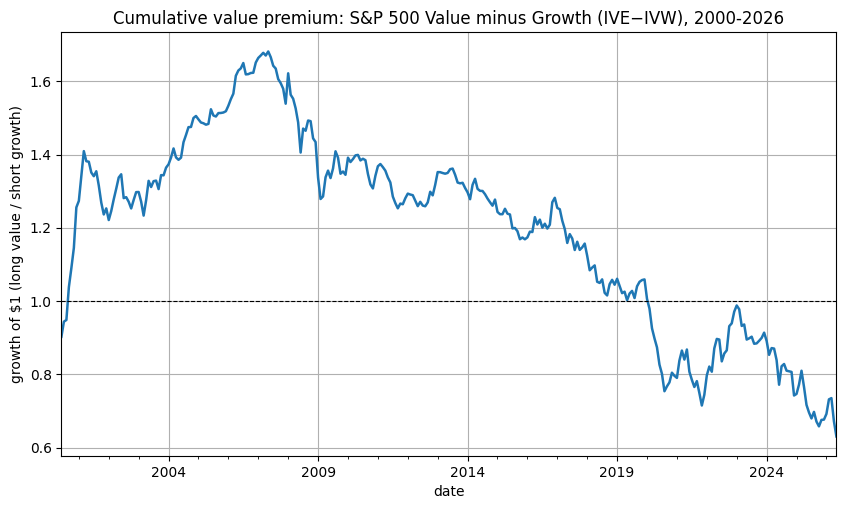

full-sample HML: -1.31%/yr, Sharpe -0.14, Lo t=-0.70


In [2]:
eq=(1+hml).cumprod()
ax=eq.plot(title='Cumulative value premium: S&P 500 Value minus Growth (IVE−IVW), 2000-2026',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1 (long value / short growth)'); plt.show()
s=st.hml_stats(hml); print(f"full-sample HML: {s['mean_ann']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, Lo t={s['tstat']:.2f}")

## 4 · The teardown

The line rises into 2007, then gives it all back over the next decade. The regime split shows exactly when the premium turned.

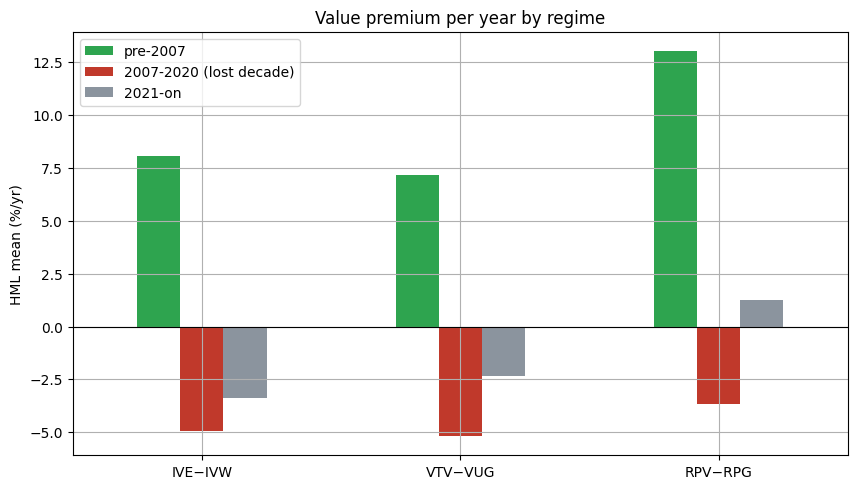

In [3]:
pairs={'IVE−IVW':('IVE','IVW'),'VTV−VUG':('VTV','VUG'),'RPV−RPG':('RPV','RPG')}
reg={k: st.regime_split(st.hml(ret,a,b))['mean_ann'] for k,(a,b) in pairs.items() if a in ret and b in ret}
R=pd.DataFrame(reg).T*100
ax=R.plot.bar(rot=0,color=['#2ea44f','#c0392b','#8b949e'],title='Value premium per year by regime')
ax.set_ylabel('HML mean (%/yr)'); ax.axhline(0,color='k',lw=.8); plt.show()

**Read it plainly.** Green before 2007, deep red 2007–2020, grey-ish since — on every pair. Value didn't die; it switched regime, and the regime that matters for today's investor (the last ~18 years) hasn't paid. Keep the hindsight caveat in view, though: the 2007/2021 cuts were picked because we know how the story went — the pre-2007 green bar on the headline pair is only 79 months.

## 5 · The verdict

**Signal: Weak** — real but regime-bound, and net-negative since 2000. **Tradability: Mirage** — a thirteen-year drawdown is unholdable. **Dependable premium?: Not supported.**

## 6 · Could you actually trade it?

You can buy a value ETF for a few basis points — but you'd have underperformed a growth ETF for two decades and sat through a lost decade. Whether value 'comes back' is a regime call, not a premium you can bank.

## 7 · Going further 🚪

The quants notebook adds the Lo t-stats and the full regime table, and the live academic debate (Israel et al. 2021 vs Arnott et al. 2021). Pair it with [Study 45 Vanishing-Act](../../45-vanishing-act/) — the size premium's disappearance — for the "are the classic factors alive?" question.